## Simple Linear Regression Task on HCIA Training

In [56]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score


In [83]:
dataset=pd.read_csv("salary_regression_data.csv")

# print(dataset.to_string())

print("Dataset Features : ",dataset.columns)
print("="*50)
print("Dataset Head :",dataset.head())
print("="*50)
print("Dataset Shape :" ,dataset.shape)
print("="*50)
print("Dataset Dscription :\n",dataset.describe())
print("="*50)
print("IS Dataset have missing Values ? ",dataset.isnull().values.any())
# print("Dataset MisingValues :",)

Dataset Features :  Index(['YearsExperience', 'MonthlySalary_EGP'], dtype='str')
Dataset Head :    YearsExperience  MonthlySalary_EGP
0              0.5               9088
1              0.6               7256
2              0.8              10761
3              0.9              11385
4              1.1               7398
Dataset Shape : (70, 2)
Dataset Dscription :
        YearsExperience  MonthlySalary_EGP
count        70.000000          70.000000
mean          5.250000       23891.671429
std           2.799521        9102.424843
min           0.500000        7256.000000
25%           2.850000       16370.250000
50%           5.250000       24169.500000
75%           7.650000       31372.500000
max          10.000000       40053.000000
IS Dataset have missing Values ?  False


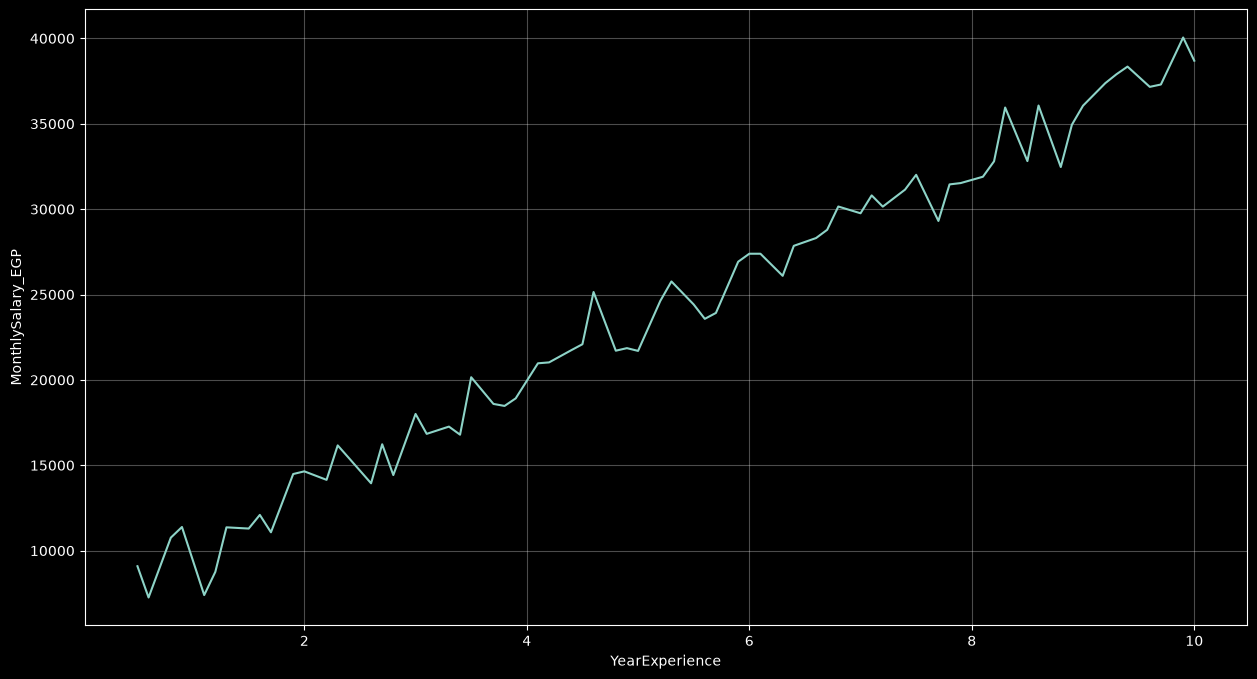

In [81]:
plt.style.use('dark_background')
plt.figure(figsize=(15,8))

# YearExp=np.array(dataset[:,1])
plt.plot(dataset['YearsExperience'],dataset['MonthlySalary_EGP'])
plt.xlabel("YearExperience")
plt.ylabel("MonthlySalary_EGP")
plt.grid(alpha=0.3)

In [59]:

# X -> input Feature , y -> Target Feature
x=dataset['YearsExperience']
y=dataset['MonthlySalary_EGP']
print(x)
print(y)

0      0.5
1      0.6
2      0.8
3      0.9
4      1.1
      ... 
65     9.4
66     9.6
67     9.7
68     9.9
69    10.0
Name: YearsExperience, Length: 70, dtype: float64
0      9088
1      7256
2     10761
3     11385
4      7398
      ...  
65    38349
66    37162
67    37300
68    40053
69    38694
Name: MonthlySalary_EGP, Length: 70, dtype: int64


In [60]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

X_train=X_train.values.reshape(-1,1)
y_train=Y_train.values.reshape(-1,1)
print(X_train.shape)
print(y_train.shape)


(56, 1)
(56, 1)


In [61]:
model=LinearRegression()
model.fit(X_train,Y_train)

print("Model Intercept :",model.intercept_)
print("Model Coefficient :",model.coef_)
print(f"Equation: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}")

Model Intercept : 7194.335072683789
Model Coefficient : [3199.12644143]
Equation: y = 3199.13x + 7194.34


In [62]:
y_pred=model.predict(Y_test.values.reshape(-1,1))
print("Prediction Set :",y_pred)

Prediction Set : [6.44887869e+07 2.90808554e+07 9.64544583e+07 2.36743317e+07
 1.00866054e+08 5.76106650e+07 4.63529391e+07 6.94218399e+07
 9.21100446e+07 4.52620370e+07 6.94602294e+07 3.54375197e+07
 1.19334611e+08 2.80219446e+07]


In [65]:
print("MAE : ",mean_absolute_error(y_true=Y_test.values.reshape(-1,1),y_pred=y_pred))
print("RMSE :",root_mean_squared_error(y_true=Y_test.values.reshape(-1,1),y_pred=y_pred))
print("R**2 Score :",r2_score(y_true=Y_test.values.reshape(-1,1),y_pred=y_pred))

MAE :  62664430.70041592
RMSE : 69141133.30531244
R**2 Score : -57276509.108942986


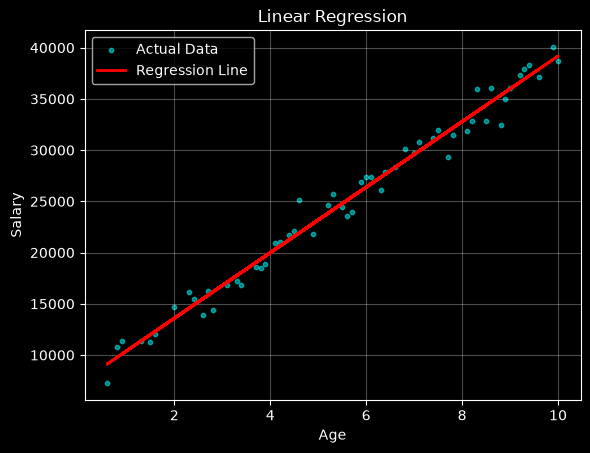

In [80]:
plt.style.use('dark_background')

# Scatter plot of actual data
plt.scatter(X_train, Y_train, color='cyan',s=10 ,alpha=0.5,label='Actual Data')

# Regression line
plt.plot(X_train, model.predict(X_train), color='red',lw=2, label='Regression Line')

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.legend()
plt.grid(alpha=0.3)


In [68]:

PredictedSalary= model.coef_*6+model.intercept_

print(f"Predicted Salary for an Employee with 6 Years of experience : {PredictedSalary[0]:.2f}")

Predicted Salary for an Employee with 6 Years of experience : 26389.09
